In [1]:
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import math, time
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
import joblib

import matplotlib.pyplot as plt
plt.rc('font', family='SimHei', size=14)  ##显示中文

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
file_path = './OutputData/水地1.xlsx'
df = pd.read_excel(file_path)
# df = df.iloc[6572:]
# 将“时间”列转换为 datetime 类型，方便按时间属性筛选
# df["时间"] = pd.to_datetime(df["时间"])
# df = df[(df["时间"].dt.minute == 0) & (df["时间"].dt.second == 0)]
# df.to_excel("./OutputData/水地1.xlsx",index=False)

In [3]:
df

,时间,监测值
0,2025-01-01 00:00:00,885.392
1,2025-01-01 02:00:00,NaN
2,2025-01-01 04:00:00,885.404
3,2025-01-01 06:00:00,NaN
4,2025-01-01 08:00:00,885.394
...,...,...
2155,2025-06-29 14:00:00,NaN
2156,2025-06-29 16:00:00,887.543
2157,2025-06-29 18:00:00,NaN
2158,2025-06-29 20:00:00,887.452


# 缺失值填充

In [4]:
df_list = []
df.set_index('时间', inplace=True)
# 使用线性插值来填充缺失的数据
df_interpolated = df.interpolate(method='linear')
# 索引重置为列
df_interpolated.reset_index(inplace=True)
#将插值后的数据加入
df_list.append(df_interpolated)
# 使用pd.concat将列表中的所有DataFrame合并成一个单一的DataFrame
df_linear = pd.concat(df_list, ignore_index=True)

In [5]:
df_linear.to_excel("./OutputData/水地1(out).xlsx",index=False)
df = df_linear
df

,时间,监测值
0,2025-01-01 00:00:00,885.3920
1,2025-01-01 02:00:00,885.3980
2,2025-01-01 04:00:00,885.4040
3,2025-01-01 06:00:00,885.3990
4,2025-01-01 08:00:00,885.3940
...,...,...
2155,2025-06-29 14:00:00,887.6210
2156,2025-06-29 16:00:00,887.5430
2157,2025-06-29 18:00:00,887.4975
2158,2025-06-29 20:00:00,887.4520


In [6]:
# 单步滚动预测函数 - 根据需求实现
def rolling_forecast_with_update(model, scaler, original_data, lookback, forecast_steps):
    """
    使用单步LSTM模型实现滚动预测并更新原数据集
    
    参数:
    model: 训练好的LSTM模型
    scaler: 用于归一化和反归一化的缩放器
    original_data: 原始数据集 (DataFrame，包含时间和监测值两列)
    lookback: 模型输入序列长度
    forecast_steps: 需要预测的未来步数
    
    返回:
    updated_data: 包含预测值的更新后的数据集
    """
    model.eval()
    
    # 确保数据格式正确
    time_column = original_data.columns[0]  # 假设第一列是时间
    value_column = original_data.columns[1]  # 假设第二列是监测值
    
    # 复制原始数据，避免修改原始数据
    data = original_data.copy()
    
    # 提取最后lookback个时间步的数据作为初始输入
    last_sequence = data[value_column].values[-lookback:].reshape(1, lookback, 1)
    
    # 归一化
    last_sequence_scaled = scaler.transform(last_sequence.reshape(-1, 1)).reshape(1, lookback, 1)
    
    # 转换为张量
    last_sequence_tensor = torch.FloatTensor(last_sequence_scaled)
    
    # 预测未来steps步
    with torch.no_grad():
        for i in range(forecast_steps):
            # 预测下一个时间步
            pred = model(last_sequence_tensor)
            pred_value = pred.item()
            
            # 反归一化预测值
            pred_value_actual = scaler.inverse_transform([[pred_value]])[0, 0]
            
            # 生成下一个时间戳（假设时间间隔均匀）
            last_time = pd.to_datetime(data[time_column].iloc[-1])
            time_delta = pd.to_datetime(data[time_column].iloc[-1]) - pd.to_datetime(data[time_column].iloc[-2])
            next_time = last_time + time_delta
            
            # 创建新的预测行
            new_row = pd.DataFrame({time_column: [next_time], value_column: [pred_value_actual]})
            
            # 将新行添加到数据集中
            data = pd.concat([data, new_row], ignore_index=True)
            
            # 更新输入序列：移除第一个时间步，添加新预测值
            new_sequence = np.roll(last_sequence_scaled, -1, axis=1)
            new_sequence[0, -1, 0] = pred_value
            last_sequence_scaled = new_sequence
            last_sequence_tensor = torch.FloatTensor(last_sequence_scaled)
    
    return data

In [7]:
# target为要输入的数据,lookback为序列长度
def split_data(target, lookback):
    data_raw = target.to_numpy() 
    data = []
    
    # you can free play（seq_length）
    for index in range(len(data_raw) - lookback + 1 ): 
        data.append(data_raw[index: index + lookback])
    
    data = np.array(data);

    # 设置测试集天数为最近30天的数据
    test_set_size = 0
    train_set_size = data.shape[0] - (test_set_size)
    
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_train, y_train, x_test, y_test]

In [8]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [9]:
# 模型超参数
input_dim = 1
hidden_dim = 50
num_layers = 2
output_dim = 1
lookback = 50
num_epochs = 750

# 该目录用于保存最优模型参数
os.makedirs('waterlevel_model', exist_ok=True)
# 该目录用于保存最优模型训练数据标准化格式
os.makedirs('waterlevel_scaler', exist_ok=True)


# 提取标签
target = df[['监测值']].copy()

#归一化
scaler = MinMaxScaler(feature_range=(-1, 1))
target['监测值'] = scaler.fit_transform(target['监测值'].values.reshape(-1,1))

best_scaler_path = 'waterlevel_scaler/' + '水地1.xlsx_scaler.pkl'
print('模型标准化格式保存路径：',best_scaler_path)

# 保存标准化参数
joblib.dump(scaler, best_scaler_path)

#划分训练集、验证集、测试集
x_train, y_train, x_test, y_test = split_data(target, lookback)

print('x_train shape:',x_train.shape)
print('y_trian shape:',y_train.shape)
print('x_test shape',x_test.shape)
print('y_test shape',y_test.shape)

# 转换成张量,神经网络模型的数据要求为张量类型
x_train = torch.from_numpy(x_train).type(torch.Tensor)
y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)

# 模型实例化准备开始训练
model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

import time

hist = np.zeros(num_epochs)
best_train_loss = float('inf')  # 用于保存验证集上的最佳损失
best_model_path = 'waterlevel_model/' + '水地1.xlsx_model.pth'  # 最佳模型保存路径
print('最优模型参数保存路径：',best_model_path)

start_time = time.time()
lstm = []

for t in range(num_epochs):
    # 训练模式
    model.train()
    
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_lstm)
    hist[t] = loss.item()
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    # 验证模式
    model.eval()
    with torch.no_grad():  # 禁用梯度计算
        #y_val_pred = model(x_val)
        y_train_pred_copy = y_train_pred.detach().numpy()
        
        # 反归一化
        y_train_pred_copy_1 = scaler.inverse_transform(y_train_pred_copy)
        y_train_1 = scaler.inverse_transform(y_train_lstm.detach().numpy())
        # 计算真实MSE
        train_loss = math.sqrt(mean_squared_error(y_train_1[:, 0], y_train_pred_copy_1[:, 0]))
        print("Epoch ", t, "Train RMSE: ", train_loss)

        # 如果验证损失更好，则保存模型
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved at epoch {t} with Test RMSE: {best_train_loss}")
    
training_time = time.time()-start_time
print("Training time: {}".format(training_time))

predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
original = pd.DataFrame(scaler.inverse_transform(y_train_lstm.detach().numpy()))

模型标准化格式保存路径： waterlevel_scaler/水地1.xlsx_scaler.pkl
x_train shape: (2111, 49, 1)
y_trian shape: (2111, 1)
x_test shape (0, 49, 1)
y_test shape (0, 1)
最优模型参数保存路径： waterlevel_model/水地1.xlsx_model.pth
Epoch  0 Train RMSE:  1.0285211930231095
Best model saved at epoch 0 with Test RMSE: 1.0285211930231095
Epoch  1 Train RMSE:  0.7266579431993035
Best model saved at epoch 1 with Test RMSE: 0.7266579431993035
Epoch  2 Train RMSE:  0.24674804688707805
Best model saved at epoch 2 with Test RMSE: 0.24674804688707805
Epoch  3 Train RMSE:  1.1274241185504656
Epoch  4 Train RMSE:  0.3587386052717854
Epoch  5 Train RMSE:  0.37586626689192615
Epoch  6 Train RMSE:  0.5209451809633223
Epoch  7 Train RMSE:  0.5584517078268008
Epoch  8 Train RMSE:  0.5463267984678272
Epoch  9 Train RMSE:  0.5090998544212857
Epoch  10 Train RMSE:  0.4588375911973506
Epoch  11 Train RMSE:  0.403695419301174
Epoch  12 Train RMSE:  0.3509351961768494
Epoch  13 Train RMSE:  0.30805378766083363
Epoch  14 Train RMSE:  0.28253713

In [10]:
# 加载最优模型参数
model.load_state_dict(torch.load(best_model_path,weights_only=True))  
model.eval()  # 将模型设置为评估模式

# 加载归一化格式
scaler = joblib.load(best_scaler_path)

 # 得到最好预测
with torch.no_grad():  # 禁用梯度计算
    y_train_pred = model(x_train)
    
# 预测值反归一化
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
# 原始值反归一化
y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())
# 计算MSE
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.3f RMSE' % (trainScore))

Train Score: 0.012 RMSE


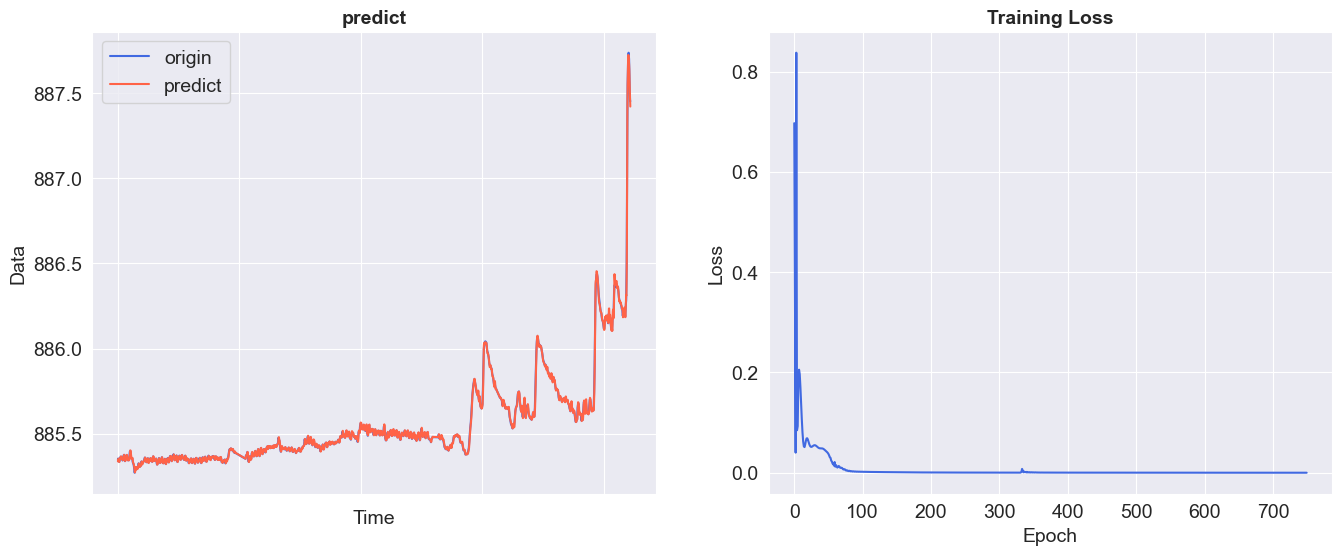

In [11]:
y_train = pd.DataFrame(y_train)
y_train_pred = pd.DataFrame(y_train_pred)

# 模型结果可视化
sns.set_style("darkgrid")
fig = plt.figure()
fig.subplots_adjust(hspace=0.2,wspace=0.2)
plt.subplot(1,2,1)
ax = sns.lineplot(x=y_train.index,y=y_train[0],label="origin",color='royalblue')
ax = sns.lineplot(x=y_train_pred.index,y=y_train_pred[0],label="predict",color='tomato')
ax.set_title(f'predict',size=14,fontweight='bold')
ax.set_xlabel("Time",size=14)
ax.set_ylabel("Data",size=14)
ax.set_xticklabels('',size=10)

plt.subplot(1,2,2)
ax = sns.lineplot(data=hist,color='royalblue')
ax.set_xlabel("Epoch",size=14)
ax.set_ylabel("Loss",size=14)
ax.set_title("Training Loss",size=14,fontweight='bold')
fig.set_figheight(6)
fig.set_figwidth(16)
plt.show()

In [12]:
data = rolling_forecast_with_update(model, scaler, df, lookback, 12)
target = data[["监测值"]]
latest_predict = target.iloc[-12:]
target

,监测值
0,885.392000
1,885.398000
2,885.404000
3,885.399000
4,885.394000
...,...
2167,887.412009
2168,887.413872
2169,887.415479
2170,887.416766


In [13]:
data

,时间,监测值
0,2025-01-01 00:00:00,885.392000
1,2025-01-01 02:00:00,885.398000
2,2025-01-01 04:00:00,885.404000
3,2025-01-01 06:00:00,885.399000
4,2025-01-01 08:00:00,885.394000
...,...,...
2167,2025-06-30 14:00:00,887.412009
2168,2025-06-30 16:00:00,887.413872
2169,2025-06-30 18:00:00,887.415479
2170,2025-06-30 20:00:00,887.416766


In [14]:
# 制作可视化数据集
# 对训练预测数据进行偏移处理
# 制作可视化数据集
trainPredictPlot = np.empty_like(target)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[lookback - 1:len(y_train_pred)+lookback - 1, :] = y_train_pred

PredictPlot = np.empty_like(target)
PredictPlot[:, :] = np.nan
PredictPlot[len(y_train_pred)+lookback-1:, :] = latest_predict

original = df[['监测值']]
OriginPlot = np.empty_like(target)
OriginPlot[:, :] = np.nan
OriginPlot[0:len(original), :] = original


# 合并所有数据
origin_df = pd.DataFrame(OriginPlot, columns=['Origin'])
train_predict_df = pd.DataFrame(trainPredictPlot, columns=['Train_Predict'])
predict_df = pd.DataFrame(PredictPlot, columns=['Latest_Predict'])
# 按列合并所有 DataFrame
result = pd.concat([data[['时间']], origin_df, train_predict_df, predict_df], axis=1)
result.to_excel('./PredictData/水地1_prediction_results.xlsx', index=False)
result

,时间,Origin,Train_Predict,Latest_Predict
0,2025-01-01 00:00:00,885.392,NaN,NaN
1,2025-01-01 02:00:00,885.398,NaN,NaN
2,2025-01-01 04:00:00,885.404,NaN,NaN
3,2025-01-01 06:00:00,885.399,NaN,NaN
4,2025-01-01 08:00:00,885.394,NaN,NaN
...,...,...,...,...
2167,2025-06-30 14:00:00,NaN,NaN,887.412009
2168,2025-06-30 16:00:00,NaN,NaN,887.413872
2169,2025-06-30 18:00:00,NaN,NaN,887.415479
2170,2025-06-30 20:00:00,NaN,NaN,887.416766
